In [1]:
import pandas as pd
import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from torch.utils.data import Dataset, DataLoader

from config import *

In [2]:
train_df = pd.read_csv(TRAIN_CSV)
train_df.head()

,text,sentiment
0,is excited to be visited by her twin and best ...,1
1,It`s fun to see that glimpse of your life,1
2,"Wow, it`s so early. Just had the best conversa...",1
3,"am chillaxin after a busy BankHoliday, Hope ev...",1
4,"Yeah, mine said 'That`s a nice picture' & gav...",1


In [3]:
train_df["text"] = train_df["text"].fillna("")
train_df["text"] = train_df["text"].astype(str)

reviews = train_df["text"]
labels = train_df["sentiment"]

print(reviews.shape)
print(labels.shape)

(23100,)
(23100,)


In [4]:
print(reviews.isna().sum())

0


In [5]:
vectorizer = TfidfVectorizer(
    ngram_range=NGRAM_RANGE,
    max_features=MAX_FEATURES
)
X_train = vectorizer.fit_transform(reviews)
y_train = labels.values

print(X_train.shape)
print(type(X_train))

(23100, 10000)
<class 'scipy.sparse._csr.csr_matrix'>


In [6]:
from src.Dataset import MyDataset
from torch.utils.data import DataLoader

train_dataset = MyDataset(
    X_train,
    y_train
)

train_loader = DataLoader(
    train_dataset,
    num_workers=4,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [7]:
import pickle

with open(VECTORIZER_PATH, "wb") as f:
    pickle.dump(vectorizer, f)

In [8]:
from src.Net import Net

net = Net()

print(net)

Net(
  (network): Sequential(
    (0): Linear(in_features=10000, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [9]:
for batch_features, batch_labels in train_loader:
    output = net(batch_features)

    print(output.shape)
    break

torch.Size([16, 3])


In [10]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    net.parameters(),
    lr=LEARNING_RATE
)

In [11]:
epochs = EPOCHS

loss_history = []

for epoch in range(epochs):
    running_loss = 0.0
    for batch_features, batch_labels in train_loader:
        optimizer.zero_grad()
        outputs = net(batch_features)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()


    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)
    print(
        f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}"
    )

Epoch [1/20] Loss: 0.7974
Epoch [2/20] Loss: 0.5360
Epoch [3/20] Loss: 0.4103
Epoch [4/20] Loss: 0.3158
Epoch [5/20] Loss: 0.2309
Epoch [6/20] Loss: 0.1641
Epoch [7/20] Loss: 0.1150
Epoch [8/20] Loss: 0.0799
Epoch [9/20] Loss: 0.0578
Epoch [10/20] Loss: 0.0424
Epoch [11/20] Loss: 0.0346
Epoch [12/20] Loss: 0.0262
Epoch [13/20] Loss: 0.0228
Epoch [14/20] Loss: 0.0205
Epoch [15/20] Loss: 0.0189
Epoch [16/20] Loss: 0.0161
Epoch [17/20] Loss: 0.0161
Epoch [18/20] Loss: 0.0138
Epoch [19/20] Loss: 0.0130
Epoch [20/20] Loss: 0.0130


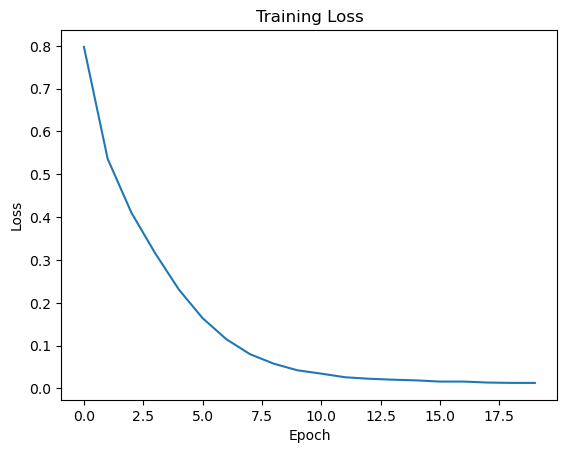

<Figure size 640x480 with 0 Axes>

In [12]:

import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()
plt.savefig(f"./experiments/{MODEL_NAME}_loss_curve")

In [13]:
torch.save(
    net.state_dict(),
    MODEL_PATH
)

In [14]:
experiment_path = f"./logs/[{MODEL_NAME}]_log.txt"

with open(experiment_path, "w") as f:

    f.write(f"""
Experiment: {MODEL_NAME}

====================
Dataset
====================

Training samples:
{len(train_dataset)}


====================
Training Parameters
====================

Seed:
{SEED}

Batch size:
{BATCH_SIZE}

Epochs:
{EPOCHS}


====================
Optimizer
====================

Optimizer:
AdamW

Learning rate:
{LEARNING_RATE}


====================
Loss
====================

CrossEntropyLoss
Label smoothing:
0.0


====================
Saved Model
====================

Path:
{MODEL_PATH}
""")

print(f"Experiment saved to: {experiment_path}")

Experiment saved to: ./logs/[sentiment_model_medium_larger_dataset]_log.txt
